In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, auc, precision_score, recall_score, f1_score, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import clone_model
from tensorflow.keras.metrics import Precision, AUC
import shap
import seaborn as sns 

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Importing the clean training and testing dataset

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
# Identify binary columns and continuous columns for scaling as we only want to scale only continuous variables

binary_cols = [c for c in train.columns if set(pd.unique(train[c].dropna())) <= {0, 1}]
cont_cols   = [c for c in train.columns if c not in binary_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), cont_cols),
        ("keep_bin", "passthrough", binary_cols),
    ]
)

# Fitting the data (it becomes a scaled array)

train_scaled_array = preprocess.fit_transform(train) 
test_scaled_array = preprocess.transform(test)

# Convert the arrays back into dataframes for data manipulation

new_cols = cont_cols + binary_cols  
train_scaled = pd.DataFrame(train_scaled_array, columns=new_cols, index=train.index)
test_scaled  = pd.DataFrame(test_scaled_array,  columns=new_cols, index=test.index)


In [4]:
# Split between genders by filtering values that is 1 for male or female
# Use the same variables as the main best model and dropping female and male columns

train_male = train_scaled[train_scaled["male"] == 1][['age', 'bmi','blood_glucose_level','hypertension','heart_disease','diabetes']]
train_female = train_scaled[train_scaled["female"] == 1][['age', 'bmi','blood_glucose_level', 'hypertension','heart_disease','diabetes']]

test_male = test_scaled[test_scaled["male"] == 1][['age', 'bmi','blood_glucose_level', 'hypertension','heart_disease','diabetes']]
test_female = test_scaled[test_scaled["female"] == 1][['age', 'bmi','blood_glucose_level', 'hypertension','heart_disease','diabetes']]

In [5]:
train_female.head()

,age,bmi,blood_glucose_level,hypertension,heart_disease,diabetes
3,1.697407,-0.447605,0.486562,0.0,0.0,0.0
4,-0.926226,0.829736,0.045817,0.0,0.0,0.0
5,0.896976,2.379420,0.511048,0.0,0.0,0.0
7,0.318888,-0.563055,-0.199042,0.0,0.0,0.0
8,1.652938,0.835657,0.045817,0.0,0.0,0.0


In [6]:
# Splitting the scaled data into "X" matrix (input) and "Y" matrix (true outcome)

x_train_male = train_male.drop(['diabetes'], axis = 1)
y_train_male = train_male[['diabetes']]

x_train_female = train_female.drop(['diabetes'], axis = 1)
y_train_female = train_female[['diabetes']]

x_test_male = test_male.drop(['diabetes'], axis = 1)
y_test_male = test_male[['diabetes']]

x_test_female = test_female.drop(['diabetes'], axis = 1)
y_test_female = test_female[['diabetes']]

In [7]:
# Best model is from the fourth test, so we use the same ann model

ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(units=22, activation='relu'))
ann.add(tf.keras.layers.Dense(units=14, activation='relu'))
ann.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

# Cloning for separate ann model

male_ann = clone_model(ann)
female_ann = clone_model(ann)

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                              patience=6)

opt_m = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)
opt_f = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)

In [8]:
# Compiling Fitting ANN, try 100 epochs with early stopping

male_ann.compile(optimizer=opt_m, loss="binary_crossentropy", 
            metrics=['accuracy', Precision(), AUC()])

male_model = male_ann.fit(x_train_male, y_train_male, batch_size = 32, verbose = 0,
                validation_split = 0.2, epochs = 100, callbacks=[callback])

In [9]:
# Compiling Fitting ANN, try 100 epochs with early stopping

female_ann.compile(optimizer=opt_f, loss="binary_crossentropy", 
            metrics=['accuracy', Precision(), AUC()])

female_model = female_ann.fit(x_train_female, y_train_female, batch_size = 32, verbose = 0,
                validation_split = 0.2, epochs = 100, callbacks=[callback])

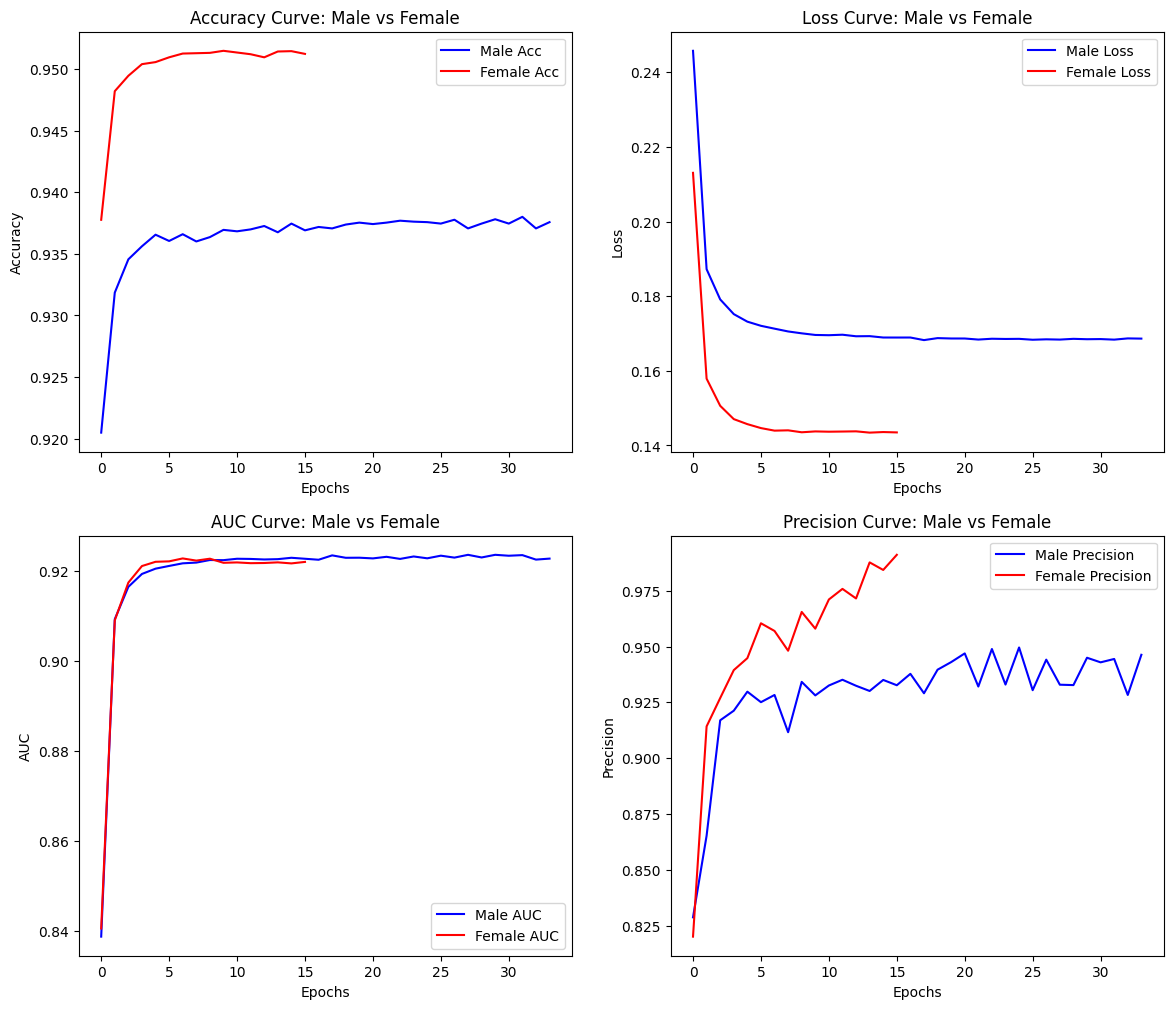

In [10]:
# Plotting Accuracy, Loss, AUC, and Precision in a 2x2 subplot

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))

# Accuracy Curve

ax1.plot(male_model.history['accuracy'], label = 'Male Acc', color = 'blue')
ax1.plot(female_model.history['accuracy'], label = 'Female Acc', color = 'red')
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy Curve: Male vs Female")
ax1.legend() 

# Loss Curve

ax2.plot(male_model.history['loss'], label = 'Male Loss', color = 'blue')
ax2.plot(female_model.history['loss'], label = 'Female Loss', color = 'red')
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.set_title("Loss Curve: Male vs Female")
ax2.legend() 

ax3.plot(male_model.history['auc'], label = 'Male AUC', color = 'blue')
ax3.plot(female_model.history['auc_1'], label = 'Female AUC', color = 'red')
ax3.set_xlabel("Epochs")
ax3.set_ylabel("AUC")
ax3.set_title("AUC Curve: Male vs Female")
ax3.legend() 

# Precision Curve

ax4.plot(male_model.history['precision'], label = 'Male Precision', color = 'blue')
ax4.plot(female_model.history['precision_1'], label = 'Female Precision', color = 'red')
ax4.set_xlabel("Epochs")
ax4.set_ylabel("Precision")
ax4.set_title("Precision Curve: Male vs Female")
ax4.legend() 

# Save the plot

# plt.savefig("Training_Metrics_Male_Female_Plot")

plt.show()


In [11]:
# Evaluate the trained ANN model on the test dataset

male_ann.evaluate(x_test_male, y_test_male, verbose = 0)

[0.17163193225860596,
 0.9374303221702576,
 0.9475138187408447,
 0.9190503358840942]

In [12]:
# Evaluate the trained ANN model on the test dataset

female_ann.evaluate(x_test_female, y_test_female, verbose = 0)

[0.13826051354408264,
 0.9514710903167725,
 0.980663001537323,
 0.9311501979827881]

In [13]:
# Extract feature names for reference in SHAP plots

feature_names_m = x_train_male.columns.tolist()

feature_names_f = x_train_female.columns.tolist()

# Convert train/test inputs to numpy arrays (float32 for compatibility with SHAP and TensorFlow)

x_train_m = x_train_male.to_numpy(dtype=np.float32)
x_train_f = x_train_female.to_numpy(dtype=np.float32)

x_test_m = x_test_male.to_numpy(dtype=np.float32)
x_test_f = x_test_female.to_numpy(dtype=np.float32)

# Select a random subset of training data as background for SHAP

bg_idx_m = np.random.choice(x_train_m.shape[0], size=min(200, x_train_m.shape[0]), replace=False)
background_m = x_train_m[bg_idx_m]

bg_idx_f = np.random.choice(x_train_f.shape[0], size=min(200, x_train_f.shape[0]), replace=False)
background_f = x_train_f[bg_idx_f]

# Create a SHAP masker that independently perturbs features using the background distribution
# Build a SHAP explainer for the ANN model

masker_m = shap.maskers.Independent(background_m)
explainer_m = shap.Explainer(ann, masker_m) 

masker_f = shap.maskers.Independent(background_f)
explainer_f = shap.Explainer(ann, masker_f)  

# Choose the first 200 test samples to explain and calculate the SHAP values

x_explain_m = x_test_m[:200]
shap_values_m = explainer_m(x_explain_m)  

x_explain_f = x_test_f[:200]
shap_values_f = explainer_f(x_explain_f)  

# Attact the feature names to the SHAP values

shap_values_m.feature_names = feature_names_m

shap_values_f.feature_names = feature_names_f

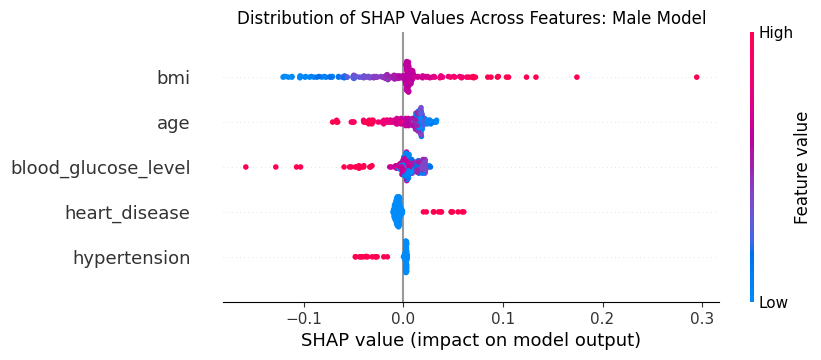

In [14]:
shap.plots.beeswarm(shap_values_m, max_display=20, show = False)
plt.title("Distribution of SHAP Values Across Features: Male Model");

# plt.savefig("SHAP_Beeswam_Male_Plot")

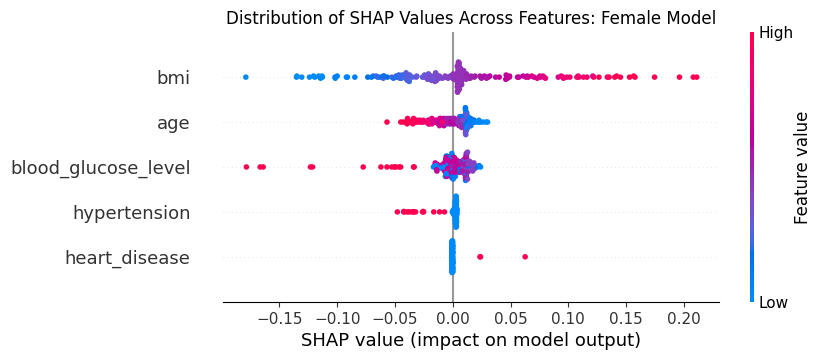

In [15]:
shap.plots.beeswarm(shap_values_f, max_display=20, show = False)
plt.title("Distribution of SHAP Values Across Features: Female Model");

# plt.savefig("SHAP_Beeswarm_Female_Plot")

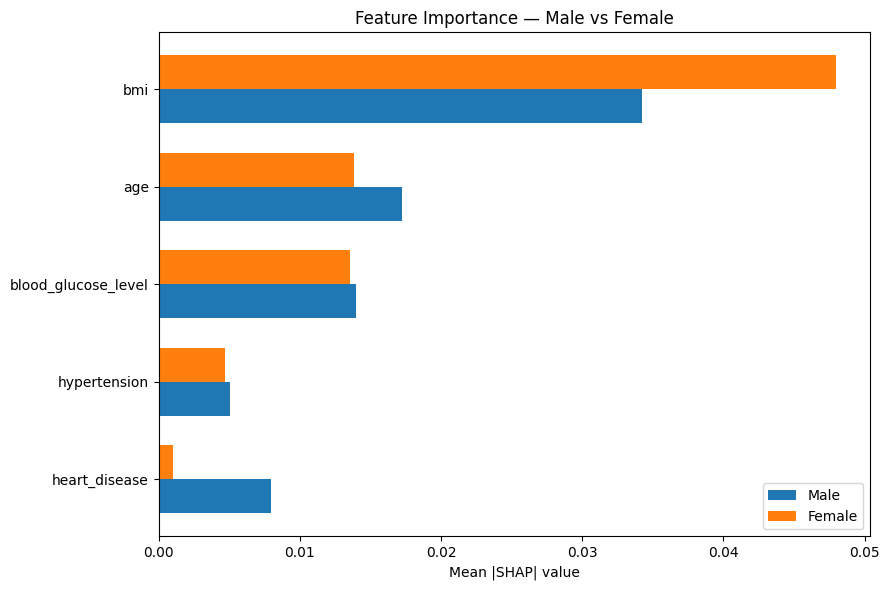

In [16]:
# Compute mean absolute SHAP per feature for each model

mean_abs_m = np.abs(shap_values_m.values).mean(axis=0)  
mean_abs_f = np.abs(shap_values_f.values).mean(axis=0)

# List of feature names for the bar plot

features = list(shap_values_m.feature_names)  

df = pd.DataFrame({
    "feature": features,
    "Male": mean_abs_m,
    "Female": mean_abs_f
})

# Pick top-k features by overall importance (average of M+F)

top_k = 10
df["avg"] = (df["Male"] + df["Female"]) / 2.0
df_top = df.sort_values("avg", ascending=False).head(top_k)

# Keep the plotting order top-to-bottom (most important at top)

df_top = df_top.iloc[::-1]

# Plot grouped horizontal bars

plt.figure(figsize=(9, 6))
y = np.arange(len(df_top))
bar_height = 0.35

plt.barh(y - bar_height/2, df_top["Male"], height=bar_height, label="Male")
plt.barh(y + bar_height/2, df_top["Female"], height=bar_height, label="Female")

plt.yticks(y, df_top["feature"])
plt.xlabel("Mean |SHAP| value")
plt.title("Feature Importance — Male vs Female")
plt.legend()
plt.tight_layout()
plt.show()

# Save the plot

# plt.savefig("FeatureImportance_Male_Female_Plot")

In [17]:
# Predict diabetes probabilities on the test dataset
# .squeeze() removes extra dimensions so we get a 1D array

y_pred_proba_m = male_ann.predict(x_test_male, verbose=0).squeeze()
y_pred_m = pd.DataFrame({"diabetes_pred": y_pred_proba_m}, index = x_test_male.index)

y_pred_proba_f = female_ann.predict(x_test_female, verbose=0).squeeze()
y_pred_f = pd.DataFrame({"diabetes_pred": y_pred_proba_f}, index = x_test_female.index)

# Combine actual labels with predicted probabilities for comparison

prediction_binary_m = pd.concat([y_test_male, y_pred_m], axis = 1)
prediction_binary_f = pd.concat([y_test_female, y_pred_f], axis = 1)

In [18]:
# Compute ROC curve points (false positive rate, true positive rate)
# roc_curve compares true labels against predicted probabilities

fpr_m, tpr_m, _ = roc_curve(y_test_male, y_pred_proba_m)
fpr_f, tpr_f, _ = roc_curve(y_test_female, y_pred_proba_f)

# Calculate the Area Under the Curve (AUC) 
# This summarizes ROC performance into a single number between 0 and 1

auc_m = roc_auc_score(y_test_male, y_pred_proba_m)
auc_f = roc_auc_score(y_test_female, y_pred_proba_f)

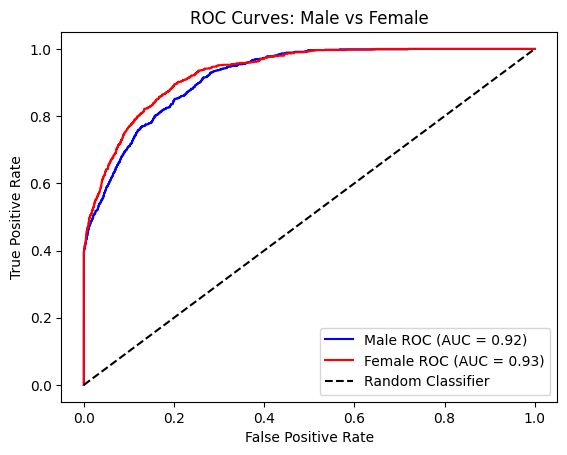

In [19]:
# Plotting ROC Curve

plt.plot(fpr_m, tpr_m, label=f"Male ROC (AUC = {auc_m:.2f})", color="blue")
plt.plot(fpr_f, tpr_f, label=f"Female ROC (AUC = {auc_f:.2f})", color="red")

# Add a diagonal line

plt.plot([0,1], [0,1], 'k--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Male vs Female")
plt.legend()

# plt.savefig("ROC_Curves_Plot")

plt.show()

In [20]:
# Convert predicted probabilities into binary values (0 or 1) based on a threshold of 0.1
# If the predicted probability ≥ 0.1, it is classified as '1' (diabetes); otherwise, '0' (no diabetes)

prediction_binary_m['diabetes_pred'] = (prediction_binary_m['diabetes_pred'] >= 0.1).astype(int)
prediction_binary_f['diabetes_pred'] = (prediction_binary_f['diabetes_pred'] >= 0.1).astype(int)

In [21]:
# Extract the true labels (y_test) and predicted binary values (y_pred) for males and females

y_test_m = prediction_binary_m['diabetes'].values
y_pred_bin_m = prediction_binary_m['diabetes_pred'].values

y_test_f = prediction_binary_f['diabetes'].values
y_pred_bin_f = prediction_binary_f['diabetes_pred'].values

In [22]:
# Generate confusion matrices for males and females
# Labels=[1, 0] means the matrix will be ordered as: [Yes Diabetes, No Diabetes]

confusion_matrix_m = confusion_matrix(y_test_m, y_pred_bin_m, labels=[1, 0])
confusion_matrix_f = confusion_matrix(y_test_f, y_pred_bin_f, labels=[1, 0])

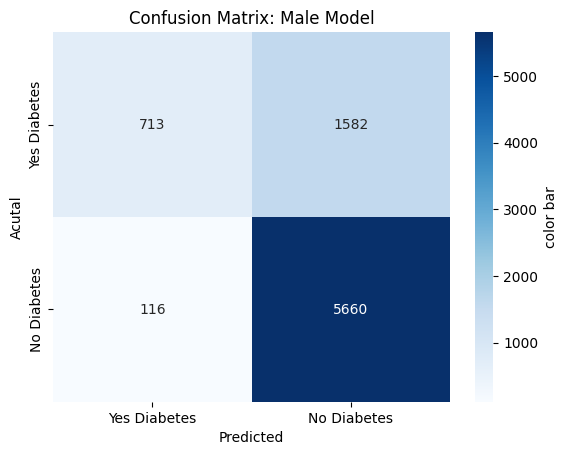

In [23]:
# Visualize the confusion matrix for males using a heatmap
# Transpose the confusion matrix so axes align correctly

sns.heatmap(confusion_matrix_m.T, cmap="Blues", annot=True, fmt='g', 
    cbar_kws={"orientation":"vertical", "label":"color bar"},xticklabels=["Yes Diabetes", "No Diabetes"],
    yticklabels=["Yes Diabetes", "No Diabetes"])
plt.title('Confusion Matrix: Male Model')
plt.xlabel("Predicted")
plt.ylabel("Acutal")
plt.show()

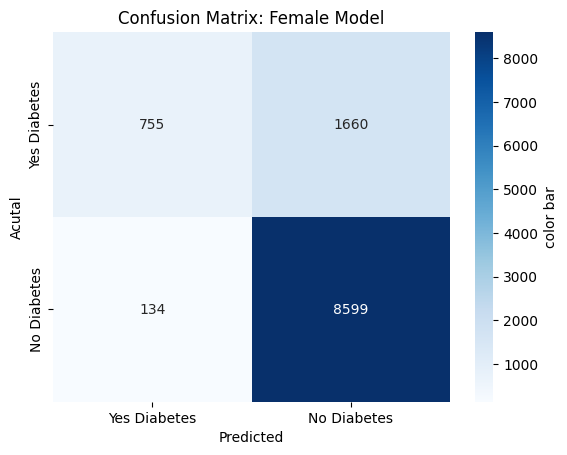

In [24]:
# Visualize the confusion matrix for females using a heatmap
# Transpose the confusion matrix so axes align correctly

sns.heatmap(confusion_matrix_f.T, cmap="Blues", annot=True, fmt='g', 
    cbar_kws={"orientation":"vertical", "label":"color bar"},xticklabels=["Yes Diabetes", "No Diabetes"],
    yticklabels=["Yes Diabetes", "No Diabetes"])
plt.title('Confusion Matrix: Female Model')
plt.xlabel("Predicted")
plt.ylabel("Acutal")
plt.show()

In [25]:
# Compute Specificity (True Negative Rate) of male: proportion of actual negatives correctly identified
# Setting pos_label=0 tells the function to treat '0' (no diabetes) as the positive class here

specificity_m = recall_score(y_test_m, y_pred_bin_m, pos_label=0)

# Compute Sensitivity (True Positive Rate) of male: proportion of actual positives correctly identified
# pos_label=1 treats '1' (diabetes) as the positive class

sensitivity_m = recall_score(y_test_m, y_pred_bin_m, pos_label=1)

# Collect all key evaluation metrics for male predictions into a dictionary

metrics_summary_male = {
    'Accuracy': accuracy_score(y_test_m, y_pred_bin_m),
    'Precision (No Diabetes)': precision_score(y_test_m, y_pred_bin_m, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_test_m, y_pred_bin_m, pos_label=0),
    'Precision (Diabetes)': precision_score(y_test_m, y_pred_bin_m, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_test_m, y_pred_bin_m, pos_label=1),
    'Sensitivity': sensitivity_m,
    'Specificity': specificity_m,
    'AUC': auc_m}

metrics_male = pd.DataFrame([metrics_summary_male])
print(metrics_male.T)

                                0
Accuracy                 0.789617
Precision (No Diabetes)  0.979917
F1-Score (No Diabetes)   0.869565
Precision (Diabetes)     0.310675
F1-Score (Diabetes)      0.456466
Sensitivity              0.860072
Specificity              0.781552
AUC                      0.919624


In [26]:
# Compute Specificity (True Negative Rate) of female: proportion of actual negatives correctly identified
# Setting pos_label=0 tells the function to treat '0' (no diabetes) as the positive class here

specificity_f = recall_score(y_test_f, y_pred_bin_f, pos_label=0)

# Compute Sensitivity (True Positive Rate) of female: proportion of actual positives correctly identified
# pos_label=1 treats '1' (diabetes) as the positive class

sensitivity_f = recall_score(y_test_f, y_pred_bin_f)

# Collect all key evaluation metrics for female predictions into a dictionary

metrics_summary_female = {
    'Accuracy': accuracy_score(y_test_f, y_pred_bin_f),
    'Precision (No Diabetes)': precision_score(y_test_f, y_pred_bin_f, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_test_f, y_pred_bin_f, pos_label=0),
    'Precision (Diabetes)': precision_score(y_test_f, y_pred_bin_f, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_test_f, y_pred_bin_f, pos_label=1),
    'Sensitivity': sensitivity_f,
    'Specificity': specificity_f,
    'AUC': auc_f}

metrics_female = pd.DataFrame([metrics_summary_female])
print(metrics_female.T)

                                0
Accuracy                 0.839074
Precision (No Diabetes)  0.984656
F1-Score (No Diabetes)   0.905539
Precision (Diabetes)     0.312629
F1-Score (Diabetes)      0.457022
Sensitivity              0.849269
Specificity              0.838191
AUC                      0.931811
